In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import KFold, cross_validate

!gdown 12G_J8gBel8MpspdXJruZuuMvyrm9upNb
!gdown 1-zjfYbZm8JC4wog9tG4zltMPuZM6p9_A

!gdown 1p03Ltdto8XoOdu14YlcQjzE-360SyI89
!gdown 1mNcWfaEW19ql8WCih6HiqRryCcjFUUqx

Downloading...
From: https://drive.google.com/uc?id=12G_J8gBel8MpspdXJruZuuMvyrm9upNb
To: /content/X_test.csv
100% 51.7k/51.7k [00:00<00:00, 64.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-zjfYbZm8JC4wog9tG4zltMPuZM6p9_A
To: /content/X_train.csv
100% 154k/154k [00:00<00:00, 15.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1p03Ltdto8XoOdu14YlcQjzE-360SyI89
To: /content/y_test.csv
100% 743/743 [00:00<00:00, 2.86MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mNcWfaEW19ql8WCih6HiqRryCcjFUUqx
To: /content/y_train.csv
100% 2.21k/2.21k [00:00<00:00, 8.72MB/s]


In [ ]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [ ]:
X_train.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single'],
      dtype='object')

In [ ]:
X_train.head()

,Age,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,36,1174,3,4,0.233871,1,0,99,3,2,...,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,21,546,5,1,0.127479,3,1,97,3,1,...,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,43,422,1,3,0.151584,4,0,33,3,2,...,2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,42,188,29,3,0.127479,2,1,56,1,2,...,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,35,992,1,3,0.127479,4,1,68,2,1,...,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
y_train.head()

,Target
0,0
1,0
2,0
3,0
4,0


In [ ]:
y_train.Target.value_counts(normalize=True)

0    0.838475
1    0.161525
Name: Target, dtype: float64

In [ ]:
smt = SMOTE()
X_sm, y_sm = smt.fit_resample(X_train, y_train)
print(y_sm.value_counts(normalize=True))

Target
0         0.5
1         0.5
dtype: float64


In [ ]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_sm, y_sm)

DecisionTreeClassifier()

In [ ]:
tree_clf.score(X_sm,y_sm)

1.0

In [ ]:
tree_clf.score(X_test,y_test)

0.7771739130434783

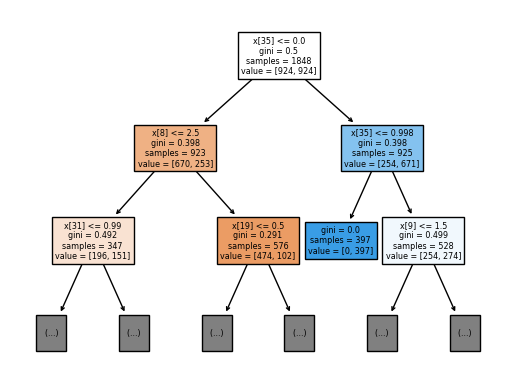

In [ ]:
plot_tree(tree_clf, filled=True, max_depth=2)
plt.show()

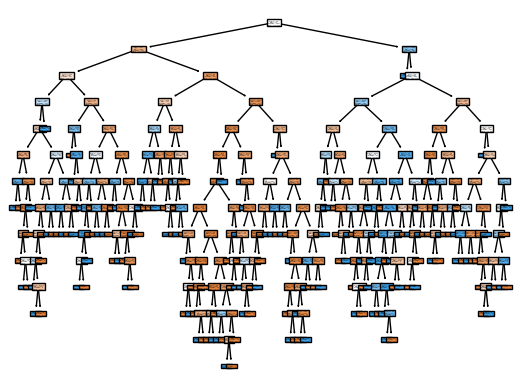

In [ ]:
plot_tree(tree_clf, filled=True)
plt.show()

In [ ]:
tree_clf.tree_.max_depth

13

In [ ]:
depths = [3,4,5,6,7,9,11,13,15, 16]
kfold = 10
for depth in depths:
    tree_clf = DecisionTreeClassifier(random_state=42, max_depth = depth)

    cv_acc_results = cross_validate(tree_clf, X_sm, y_sm, cv = kfold, scoring = 'f1', return_train_score = True)

    print(f"K-Fold for depth:{depth} Accuracy Mean: Train: {cv_acc_results['train_score'].mean()*100} Validation: {cv_acc_results['test_score'].mean()*100}")
    print("-="*20)

K-Fold for depth:3 Accuracy Mean: Train: 78.3341333009316 Validation: 74.4081731077839
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:4 Accuracy Mean: Train: 81.90292588214051 Validation: 76.26808487908902
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:5 Accuracy Mean: Train: 84.91585752830393 Validation: 77.73838752935613
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:6 Accuracy Mean: Train: 89.28711752115412 Validation: 80.71213445349518
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:7 Accuracy Mean: Train: 92.45600779802466 Validation: 82.33403766203897
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:9 Accuracy Mean: Train: 97.23580706228829 Validation: 81.66492737782175
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:11 Accuracy Mean: Train: 99.1774966495656 Validation: 82.57266666154115
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
K-Fold for depth:13 Accuracy Mean: Train: 99.78990443209466 Validation: 82.00185712408894
-=

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth = 5)
tree_clf.fit(X_sm, y_sm)

DecisionTreeClassifier(max_depth=5)

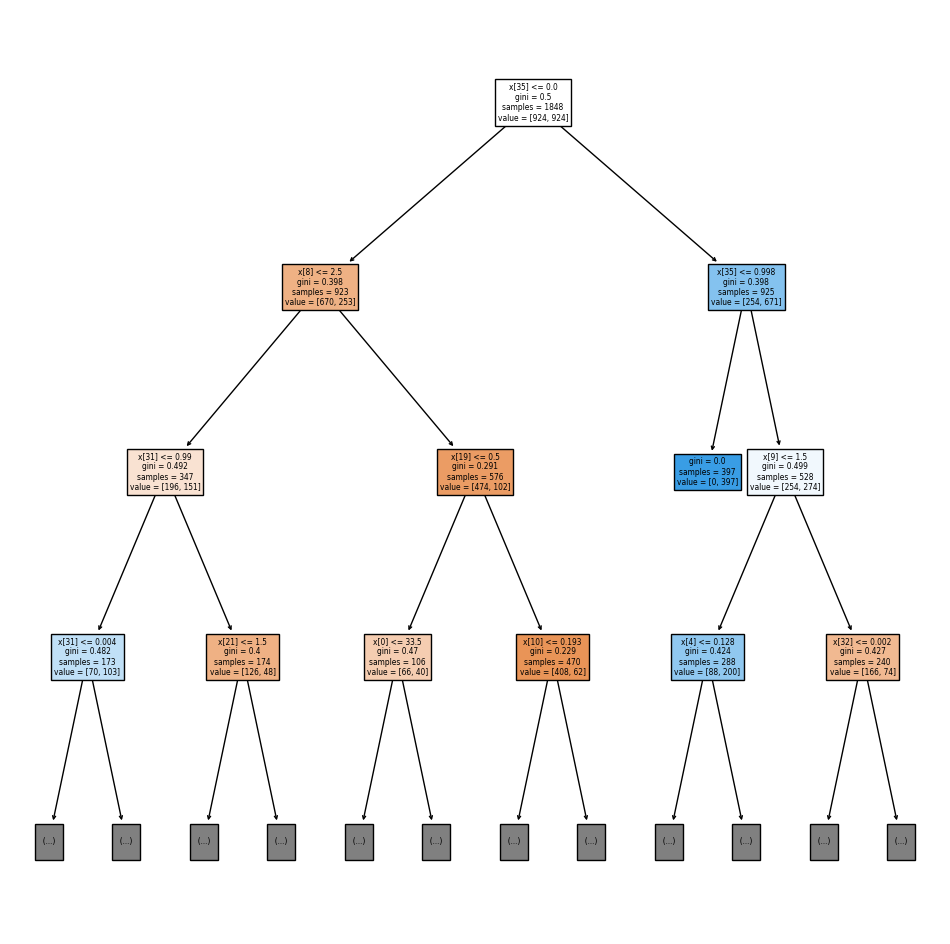

In [ ]:
plt.figure(figsize = (12, 12))
plot_tree(tree_clf, filled=True, max_depth = 3)
plt.show()

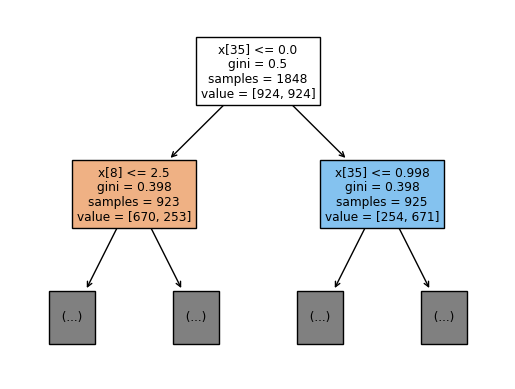

In [ ]:
plot_tree(tree_clf, filled=True, max_depth = 1)
plt.show()

In [ ]:
tree_clf.feature_importances_

array([0.01971914, 0.        , 0.        , 0.        , 0.03332049,
       0.        , 0.        , 0.        , 0.05243441, 0.07095256,
       0.04604122, 0.        , 0.02130591, 0.        , 0.00606614,
       0.        , 0.        , 0.        , 0.        , 0.01894342,
       0.        , 0.01846892, 0.        , 0.00727158, 0.01420503,
       0.00918998, 0.        , 0.        , 0.00900369, 0.0072177 ,
       0.        , 0.10274194, 0.03036635, 0.        , 0.        ,
       0.53275151])